In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)

gradient descent multiple features

In [2]:

def J_wb(x,y,w,b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb_i = np.dot(w,x[i]) + b
        cost += (f_wb_i - y[i])**2
    return cost/(2*m)


def gradient(x,y,w,b):
    m,n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        err = (np.dot(w,x[i]) + b) - y[i]

        for j in range(n):
            dj_dw[j] += err * x[i,j]

        dj_db += err
    
    return dj_dw/m , dj_db/m 


def gradient_dest(x,y,alpha,iteration):
    _,n = x.shape
    w = np.zeros(n)
    b = 0
    J_hist = []
    for i in range(iteration):
        dj_dw_i,dj_db_i = gradient(x,y,w,b)

        w = w - (alpha * dj_dw_i)
        b = b - alpha * dj_db_i

        if i<100000:
            J_hist.append(J_wb(x,y,w,b))
    
    return w,b,J_hist

In [3]:
x = np.arange(0,20,1)
y = 1 + x**2
X = x.reshape(-1,1)
model_w, model_b, _ = gradient_dest(X, y, alpha=1e-5, iteration=10000)

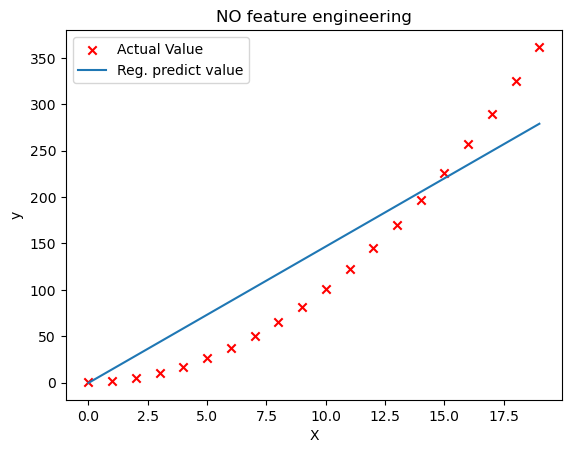

In [4]:
# multiple_linear_regression
plt.scatter(x,y,marker="x",c="red",label="Actual Value")
plt.plot(x, X@model_w + model_b, label="Reg. predict value")
plt.title("NO feature engineering")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [5]:
x = np.arange(0,20,1)
y = 1+x**2
X = x**2 #engineer features

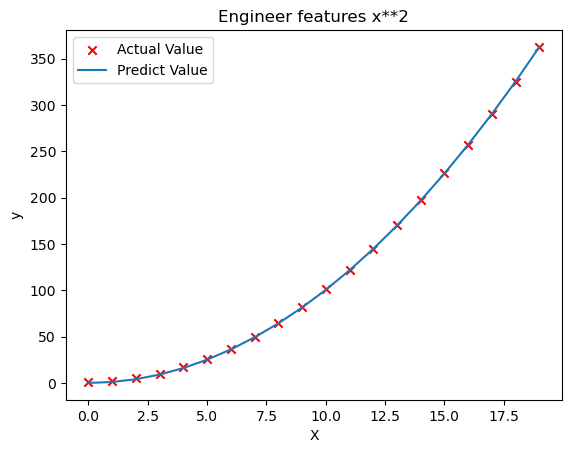

In [6]:
X = X.reshape(-1,1)
model_w, model_b, _ = gradient_dest(X,y,alpha=1e-5,iteration=10000)
plt.scatter(x, y, marker="x", c="r", label="Actual Value")
plt.plot(x, X@model_w + model_b, label="Predict Value")
plt.title("Engineer features x**2")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [7]:
x = np.arange(0,20,1)
y = x**2
X = np.c_[x,x**2,x**3]
X #engineer features

array([[   0,    0,    0],
       [   1,    1,    1],
       [   2,    4,    8],
       [   3,    9,   27],
       [   4,   16,   64],
       [   5,   25,  125],
       [   6,   36,  216],
       [   7,   49,  343],
       [   8,   64,  512],
       [   9,   81,  729],
       [  10,  100, 1000],
       [  11,  121, 1331],
       [  12,  144, 1728],
       [  13,  169, 2197],
       [  14,  196, 2744],
       [  15,  225, 3375],
       [  16,  256, 4096],
       [  17,  289, 4913],
       [  18,  324, 5832],
       [  19,  361, 6859]])

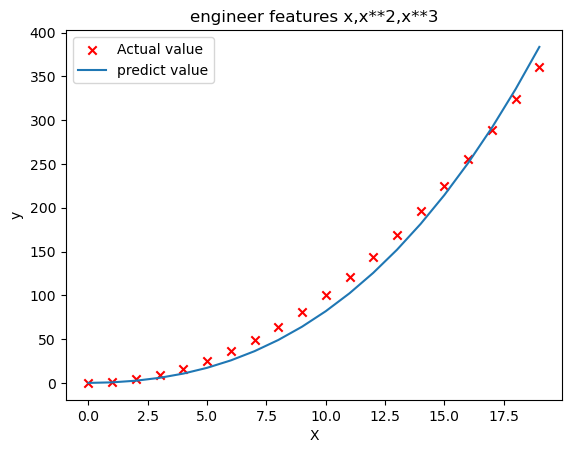

In [8]:
model_w,model_b,_ = gradient_dest(X,y,alpha=1e-7,iteration=10000)

plt.scatter(x,y,marker="x",c="r",label="Actual value")
plt.plot(x, X@model_w + model_b,label="predict value")
plt.title("engineer features x,x**2,x**3")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

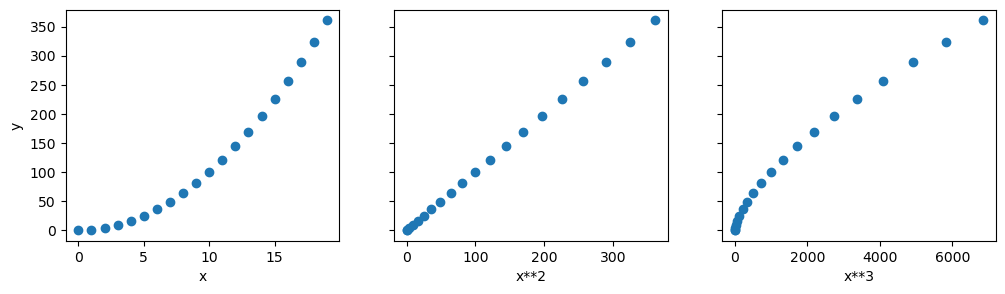

In [9]:
x = np.arange(0,20,1)
y = x**2
X = np.c_[x,x**2,x**3]
features = ["x","x**2","x**3"]

fig,ax = plt.subplots(1,3,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i],y)
    ax[i].set_xlabel(features[i])
ax[0].set_ylabel("y")
plt.show()

In [17]:
# (z score normalizaiton)
def zscore_norm(x):
    mu = np.mean(x,axis=0)
    sigma = np.std(x,axis=0)
    x = (x-mu)/sigma
    return x

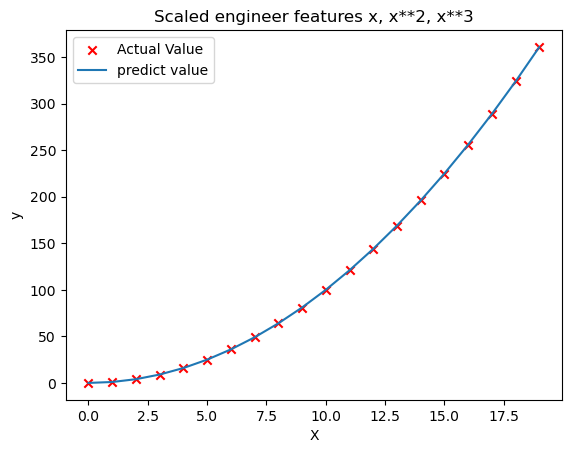

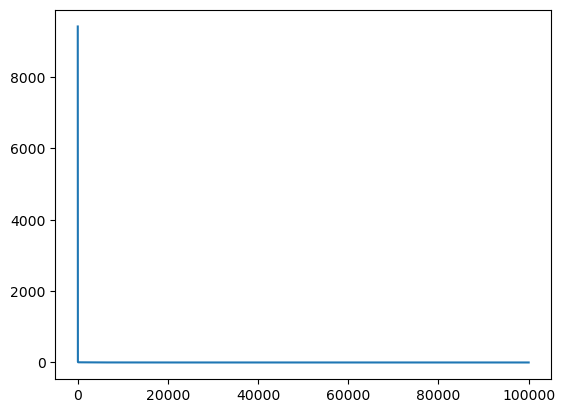

In [18]:
# scaling features 
x = np.arange(0,20,1)
y = x**2
X = np.c_[x,x**2,x**3]
X = zscore_norm(X)
model_w,model_b,J_hist = gradient_dest(X,y,alpha=1e-1,iteration=1000000)
plt.scatter(x,y,marker="x",c="r",label="Actual Value")
plt.plot(x,X@model_w+model_b,label="predict value")
plt.title("Scaled engineer features x, x**2, x**3")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()
plt.plot(J_hist)
plt.show()

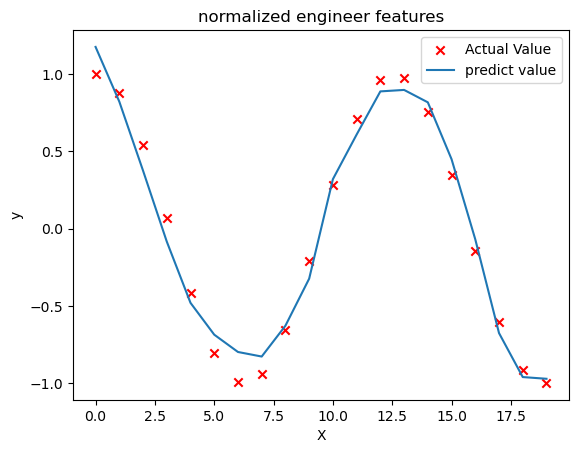

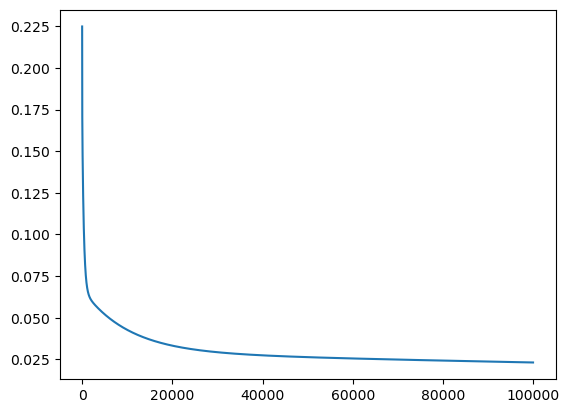

In [19]:
# more complex 
x = np.arange(0,20,1)
y = np.cos(x/2)
X = np.c_[x,x**2,x**3,x**4,x**5,x**6,x**7,x**8,x**9,x**10,x**11,x**12,x**13]
X = zscore_norm(X)
model_w,model_b,J_hist = gradient_dest(X,y,alpha=1e-1,iteration=1000000)
plt.scatter(x,y,marker="x",c="r",label="Actual Value")
plt.plot(x, X@model_w + model_b, label="predict value")
plt.title("normalized engineer features")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()
plt.plot(J_hist)
plt.show()
